#### Etape 4.2 : Visualisations Seaborn
Produire les visualisations suivantes avec Seaborn :

1. Pairplot des consommations (electricite, gaz, eau) par saison
2. Violin plot de la consommation electrique par type de batiment
3. Heatmap annotee de la matrice de correlation complete
4. FacetGrid : evolution mensuelle par commune (top 6 communes)
5. Jointplot : relation surface vs consommation avec distributions marginales
6. Catplot : consommation par classe energetique et type de batiment

**Livrables** :
- Notebook `10_visualisations_seaborn.ipynb`
- 6 figures PNG (300 dpi) dans `output/figures/`

In [15]:
import seaborn as sns

import os
import pandas as pd

INPUT_DIR = os.path.join("../output", "consommations_enrichies.csv")
OUTPUT_DIR = os.path.join("../output", "figures")
INPUT_METEO = os.path.join("../output", "meteo_clean.csv")

INPUT_DIR_MATRIX = os.path.join("../output", "matrice_correlation.csv")



In [16]:
df_conso = pd.read_csv(INPUT_DIR)
df_meteo = pd.read_csv(INPUT_METEO)

df_fusion_meteo = df_conso \
    .merge(
        df_meteo, on = ['date', 'hour', 'commune', 'month'],
        how = "left"
    )

print(df_fusion_meteo.dtypes)

print("nb lignes :\n", len(df_fusion_meteo))

Unnamed: 0                            int64
batiment_id                             str
type                                    str
commune                                 str
type_energie                            str
conso_clean                         float64
unite                                   str
date                                    str
hour                                  int64
year                                  int64
month                                 int64
classe_energetique                      str
conso_annuelle                      float64
conso_moyenne_par_occupant_annee    float64
conso_m2                            float64
conso_m2_annee                      float64
cout_horaire                        float64
cout_juor                           float64
cout_mois                           float64
cout_annee                          float64
ipe                                 float64
ecart_ipe                           float64
timestamp                       

1. Pairplot des consommations (electricite, gaz, eau) par saison

In [17]:
#on flat les type_energie
df_flatten_pair_plot = df_fusion_meteo \
    .groupby(
        ["batiment_id", "year", "month", "season", "type_energie"],
        as_index=False
    ).agg(conso=("conso_clean", "sum")) \
    .pivot(
        index=["batiment_id", "year", "month", "season"],
        columns="type_energie",
        values="conso"
    ) \
    .reset_index()

print(df_flatten_pair_plot.dtypes)

type_energie
batiment_id        str
year             int64
month            int64
season             str
eau            float64
electricite    float64
gaz            float64
dtype: object


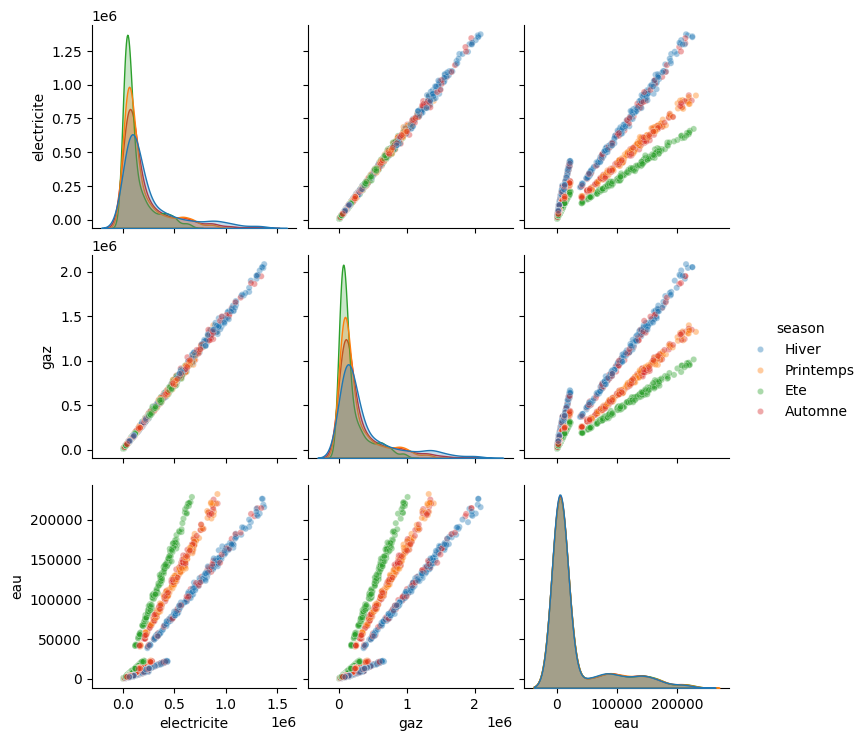

In [18]:
from matplotlib import pyplot as plt


df_pair = df_flatten_pair_plot[["electricite", "gaz", "eau", "season"]].dropna()

sns.pairplot(
    df_pair,
    vars=["electricite", "gaz", "eau"],
    hue="season",
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 20}
)

plt.savefig(f"{OUTPUT_DIR}/seaborn/pair_plot.png", dpi=300, bbox_inches="tight")

plt.show()

2. Violin plot de la consommation electrique par type de batiment

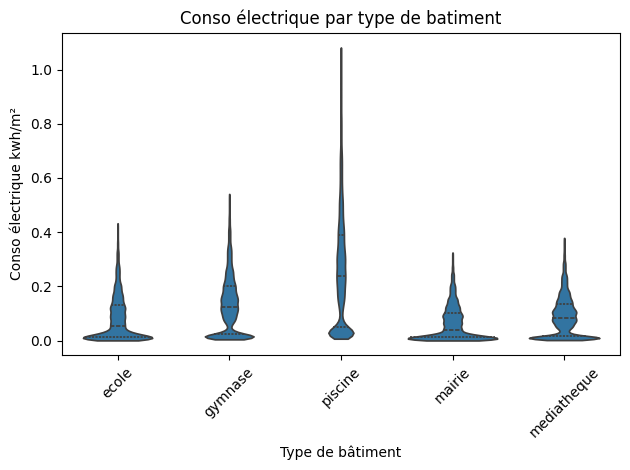

In [19]:
df_elec = df_conso[df_conso["type_energie"] == "electricite"]

plt.figure()

sns.violinplot(
    data=df_elec,
    x="type",
    y="conso_m2",
    inner="quartile",
    cut=0
)

plt.xlabel("Type de bâtiment")
plt.ylabel("Conso électrique kwh/m²")
plt.title("Conso électrique par type de batiment")

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    f"{OUTPUT_DIR}/seaborn/violin_conso_elec_par_type.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

3. Heatmap annotee de la matrice de correlation complete

In [28]:
df_matrix = pd.read_csv(INPUT_DIR_MATRIX)


df_matrix = df_matrix.drop(columns=["type_energie"])

df_matrix = df_matrix.apply(pd.to_numeric, errors="coerce")

print(df_matrix["annee_construction"].dtype)
print(df_matrix.dtypes)

corr = df_matrix.corr()

float64
annee_construction         float64
month                      float64
surface_m2                 float64
temperature_c              float64
humidite_pct               float64
rayonnement_solaire_wm2    float64
vitesse_vent_kmh           float64
precipitation_mm           float64
eau                        float64
electricite                float64
gaz                        float64
dtype: object


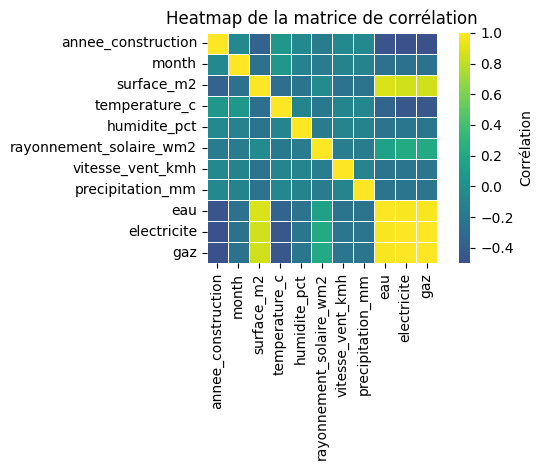

In [29]:
sns.heatmap(
    corr,
    cmap="viridis",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Corrélation"}
)

plt.title("Heatmap de la matrice de corrélation")
plt.tight_layout()
plt.savefig(
    f"{OUTPUT_DIR}/seaborn/heatmap_matrice_correlation.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

4. FacetGrid : evolution mensuelle par commune (top 6 communes)

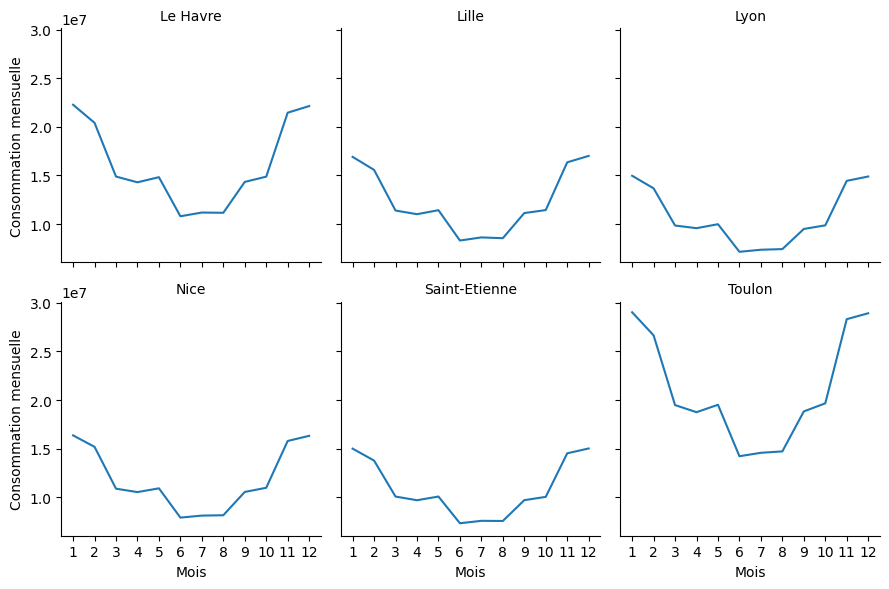

In [ ]:
# les six plus grosses communes
df_big_communes = df_conso.groupby("commune")["conso_clean"] \
    .sum() \
    .sort_values(ascending=False) \
    .head(6) \
    .reset_index()["commune"] \
    .tolist() 


df_big_communes = df_conso[df_conso["commune"].isin(df_big_communes)]


df_big_communes_month = (
    df_big_communes
    .groupby(["commune", "month"])
    .agg(conso_mensuelle=("conso_clean", "sum"))
    .reset_index()
)

g = sns.FacetGrid(
    df_big_communes_month,
    col="commune",
    col_wrap=3,
    height=3,
    sharey=True
)

g.map_dataframe(
    sns.lineplot,
    x="month",
    y="conso_mensuelle"
)

g.set_axis_labels("Mois", "Conso mensuelle kwh/m²")
g.set_titles("{col_name}")

for ax in g.axes.flatten():
    ax.set_xticks(range(1, 13))

plt.tight_layout()
plt.savefig(
    f"{OUTPUT_DIR}/seaborn/facet_evolution_mensuelle_top_communes.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

5. Jointplot : relation surface vs consommation avec distributions marginales

ValueError: Could not interpret value `surface_m2` for `x`. An entry with this name does not appear in `data`.

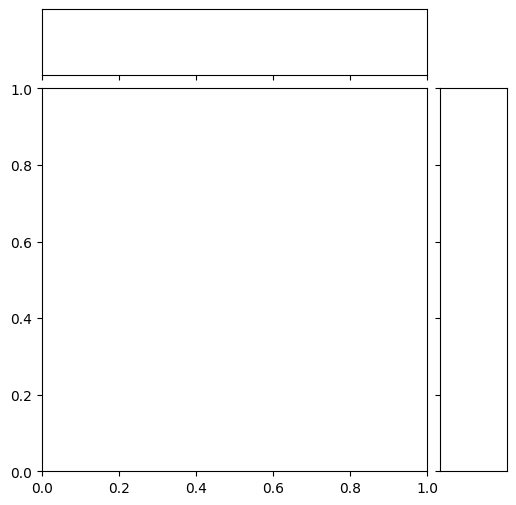

In [ ]:
#TODO 

# batiment_id                             str
# type                                    str
# commune                                 str
# type_energie                            str
# conso_clean                         float64
# unite                                   str
# date                                    str
# hour                                  int64
# year                                  int64
# month                                 int64
# classe_energetique                      str
# conso_annuelle                      float64
# conso_moyenne_par_occupant_annee    float64
# conso_m2                            float64
# conso_m2_annee                      float64
# cout_horaire                        float64
# cout_juor                           float64
# cout_mois                           float64
# cout_annee                          float64
# ipe                                 float64
# ecart_ipe                           float64
# timestamp                               str
# temperature_c                       float64
# humidite_pct                        float64
# rayonnement_solaire_wm2             float64
# vitesse_vent_kmh                    float64
# precipitation_mm                    float64
# day                                 float64
# day_of_week                         float64
# season                                  str


# sns.jointplot(
#     data=df_conso,
#     x="surface_m2",
#     y="conso_annuelle",
#     kind="scatter",
#     marginal_kws={"bins": 30},
#     joint_kws={"alpha": 0.3, "s": 15}
# )

# plt.suptitle(
#     "Surface / conso annuelle",
#     y=1.02
# )
# plt.tight_layout()
# plt.show()

6. Catplot : consommation par classe energetique et type de batiment

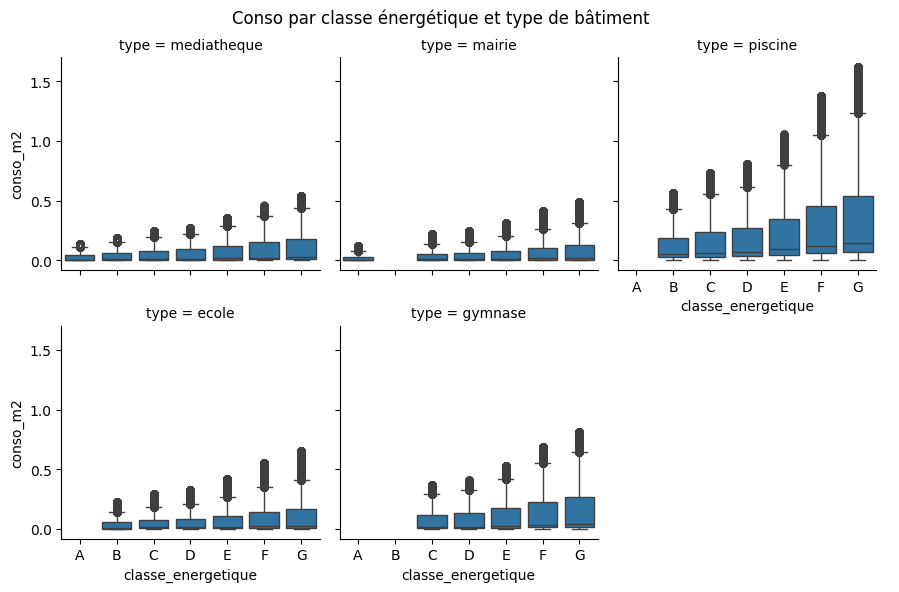

In [47]:
df_catplot = df_conso.sort_values("classe_energetique")

sns.catplot(
    data=df_catplot,
    x="classe_energetique",
    y="conso_m2",
    col="type",
    kind="box",
    col_wrap=3,
    height=3
)

plt.savefig(
    f"{OUTPUT_DIR}/seaborn/cat_plot_conso_type_batiment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.subplots_adjust(top=0.9)
plt.suptitle("Conso par classe énergétique et type de bâtiment")
plt.show()

#### Etape 4.3 : Dashboard executif
Creer un dashboard multi-panneaux (2x3) synthetisant les resultats :

- Panel 1 : Evolution de la consommation totale (6 derniers mois)
- Panel 2 : Top 10 batiments les plus energivores (bar horizontal)
- Panel 3 : Repartition des couts par type d'energie (pie chart)
- Panel 4 : Consommation moyenne par classe DPE avec ecart-type
- Panel 5 : Carte de chaleur par commune
- Panel 6 : Economies potentielles par amelioration du DPE

    date_mois  conso_totale
18 2024-07-01  5.166906e+07
19 2024-08-01  5.181719e+07
20 2024-09-01  6.668040e+07
21 2024-10-01  6.932906e+07
22 2024-11-01  9.997093e+07
23 2024-12-01  1.035311e+08


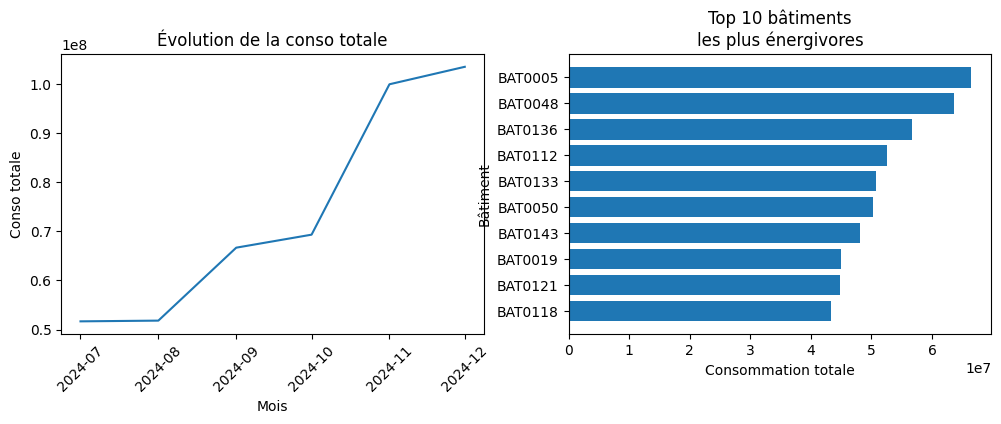

In [ ]:
# Creer le dashboard
from matplotlib.gridspec import GridSpec


#1 1 : Evolution de la consommation totale (6 derniers mois)

df_conso["date_mois"] = pd.to_datetime(
    df_conso["year"].astype(str) + "-" +
    df_conso["month"].astype(str) + "-01"
)

df_month = (
    df_conso
    .groupby("date_mois", as_index=False)
    .agg(conso_totale=("conso_clean", "sum"))
)

date_max = df_month["date_mois"].max()

df_6_derniers_mois = (
    df_month[df_month["date_mois"] >= date_max - pd.DateOffset(months=5)]
    .sort_values("date_mois")
)

print(df_6_derniers_mois)

fig = plt.figure(figsize=(12, 8))

gs = GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
ax1.set_title("Évolution de la conso totale")
ax1.set_xlabel("Mois")
ax1.set_ylabel("Conso totale")

ax1.plot(
    df_6_derniers_mois["date_mois"],
    df_6_derniers_mois["conso_totale"]
)

ax1.tick_params(axis="x", rotation=45)



#2 

df_top10_batiment = (
    df_conso
    .groupby("batiment_id", as_index=False)
    .agg(conso_totale=("conso_clean", "sum"))
    .sort_values("conso_totale", ascending=False)
    .head(10)
)


ax2 = fig.add_subplot(gs[0, 1])
ax2.barh(
    df_top10_batiment["batiment_id"],
    df_top10_batiment["conso_totale"]
)

ax2.set_title("Top 10 bâtiments\nles plus énergivores")
ax2.set_xlabel("Consommation totale")
ax2.set_ylabel("Bâtiment")

ax2.invert_yaxis()

#3

